---
title: "3D-Var methane retrieval — primal vs whitened vs dual"
---

# 3D-Var methane retrieval on a synthetic plume

This notebook is the practical companion to [00_3dvar_derivation.md](00_3dvar_derivation.md). We build a **realistic** synthetic methane plume — a steady Gaussian plume from a point source under a westerly wind, advected and dispersed downwind — push it through the JAX forward operator from `plume_simulation.assimilation`, and run the variational retrieval **three** ways:

1. **Primal LBFGS in model space** — the textbook formulation. The cost calls `gaussx.solve(B, ·)` once per gradient evaluation, so the structured `B` stays cheap.
2. **Whitened LBFGS** — same minimiser, but the control variable is $\xi = U^{-1}\delta x$ with $B = U U^\top$ (`gaussx.cholesky`). The Hessian becomes identity-plus-low-rank — see [eq-hess-whitened](00_3dvar_derivation.md#eq-hess-whitened). On this small (1024-pixel) demo both formulations converge in seconds; the whitening payoff is *qualitative*, scaling with prior conditioning and state size, and is what makes operational-scale 3D-Var feasible.
3. **Dual / PSAS** — solve $(H'BH'^\top + R)\lambda = d$ then back-substitute $\delta\hat x = BH'^\top \lambda$. For a linear forward this matches the primal solution exactly and is much cheaper when $\dim(y) \ll \dim(x)$.

All three should land at the same posterior up to tolerance — that's our headline check.

The same notebook also makes the connection to the matched filter from PR #24: the matched-filter analytic estimator is what falls out of the dual recipe with one CG iteration and a particular choice of $B$ and $R$.

In [1]:
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

jax.config.update("jax_enable_x64", True)

from plume_simulation.assimilation import (
    RadianceObservationModel,
    WhiteningTransform,
    build_cost_xi,
    build_kronecker_background,
    posterior_covariance_proxy,
    reduced_chi_squared,
    run_dual_psas,
    run_lbfgs,
)
from plume_simulation.assimilation.cost import build_cost_x
from plume_simulation.gauss_plume.plume import simulate_plume
from plume_simulation.radtran.srf import SpectralResponseFunction

## 1. Load the HAPI CH₄ absorption LUT

We use the cached methane cross-section LUT built by [01_hapi_lut_ch4.ipynb](../hapi_lut/01_hapi_lut_ch4.ipynb) — full Voigt line shapes from HITRAN over the 2.3 µm SWIR window (4000–4500 cm⁻¹). The full LUT has 10 000 wavenumber samples; we subsample it down so the obs vector stays small enough that the dual PSAS path is competitive on the demo. (At operational hyperspectral resolution you'd keep the full grid and rely on the structured `B` to keep the *primal* path fast.)

In [2]:
LUT_PATH = Path("../../data/hapi_lut/ch4_absorption_lut.nc")
lut_full = xr.open_dataset(LUT_PATH)
nu_stride = 100
lut = lut_full.isel(wavenumber=slice(None, None, nu_stride))
nu = lut["wavenumber"].values
print(f"LUT (stride {nu_stride}): {dict(lut.sizes)}")
print(f"σ range: [{float(lut.absorption_cross_section.min()):.2e}, "
      f"{float(lut.absorption_cross_section.max()):.2e}] cm²/molecule")

LUT (stride 100): {'wavenumber': 100, 'temperature': 3, 'pressure': 3}
σ range: [2.49e-24, 3.40e-20] cm²/molecule


## 2. Build a hyperspectral SRF and the JAX observation operator

Hyperspectral here means one band per wavenumber sample, so the SRF is essentially the identity — keeps the demo focused on the variational solvers rather than band integration.

In [3]:
wl = 1e7 / nu
sort = np.argsort(wl)
srf = SpectralResponseFunction(
    wavelengths_hr_nm=wl[sort],
    band_centers_nm=wl[sort],
    band_widths_nm=np.full(wl.size, 5.0),
    band_names=tuple(f"c{i}" for i in range(wl.size)),
    srf_type="gaussian",
)

model = RadianceObservationModel.from_lut(
    lut,
    nu_obs=nu,
    srf=srf,
    T_K=280.0,
    p_atm=1.0,
    path_length_cm=8.4e5,    # ≈ slant column for a satellite SWIR observation
    amf=2.0,
    vmr_reference=0.0,
)
forward_nl = jax.jit(model.make_forward(linear=False))
forward_lin = jax.jit(model.make_forward(linear=True))
print(f"Obs model: n_bands={model.n_bands}, n_lambda={model.n_lambda}")

Obs model: n_bands=100, n_lambda=100


## 3. Inject a *realistic* methane plume

Instead of a hand-crafted radial Gaussian, we use the steady Gaussian-plume forward model from [`plume_simulation.gauss_plume`](../../src/plume_simulation/gauss_plume/) — a point source emits CH₄ at 5 t/h (typical for a moderate fugitive emission at an oil & gas facility), 4 m/s wind from the west, Pasquill–Gifford stability class D (neutral). The result is the classic elongated, asymmetric plume that real airborne and satellite imagers see.

We then convert the column mass density (kg/m²) into a column-VMR enhancement (mol/mol) and scale to a peak of about 5 ppm, comfortably above instrument noise but well within the linear regime.

In [4]:
ny, nx = 32, 32
domain_extent_m = 1500.0    # 1.5 km × 1.5 km scene → ~47 m/pixel
ds_plume = simulate_plume(
    emission_rate=5.0 / 3600.0 * 1000.0,  # 5 t/h → kg/s = 1.39 kg/s
    source_location=(domain_extent_m * 0.20, domain_extent_m * 0.50, 30.0),  # left-of-centre, 30 m stack
    wind_speed=4.0,
    wind_direction=270.0,                  # wind *from* the west → flowing east
    stability_class="D",
    domain_x=(0.0, domain_extent_m, nx),
    domain_y=(0.0, domain_extent_m, ny),
    domain_z=(0.0, 100.0, 21),
    background_conc=0.0,
)
column_kg_per_m2 = ds_plume["column_concentration"].transpose("y", "x").values

# Convert column kg/m² → column VMR enhancement (mol/mol), then scale.
# (The forward model is linear in ΔVMR so the absolute scale just sets SNR;
# we pick a 5 ppm peak that's plume-like but stays in the linear regime.)
truth_field = jnp.asarray(column_kg_per_m2 / column_kg_per_m2.max() * 5e-6)
print(f"Truth Δ-VMR range: [{float(truth_field.min()):.2e}, {float(truth_field.max()):.2e}] mol/mol")
print(f"  → peak = {float(truth_field.max()) * 1e6:.1f} ppm above background")

Truth Δ-VMR range: [0.00e+00, 5.00e-06] mol/mol
  → peak = 5.0 ppm above background


In [5]:
# Forward + observe with realistic SWIR per-band radiance noise.
y_clean = forward_nl(truth_field)
rng = np.random.default_rng(42)
noise_std = 5e-4                # ~0.05 % of normalised radiance (typical hyperspectral SNR ~ 200)
y_obs = y_clean + jnp.asarray(rng.normal(scale=noise_std, size=y_clean.shape))
print(f"Obs cube shape: {y_obs.shape},  per-band noise σ = {noise_std:.0e}")

Obs cube shape: (32, 32, 100),  per-band noise σ = 5e-04


**Sanity figure**: the truth field (left) is an asymmetric plume elongated downwind from the source. The observed radiance at the strongest CH₄ band (right) shows a clear absorption "shadow" along the plume — that's the signal the retrieval inverts.

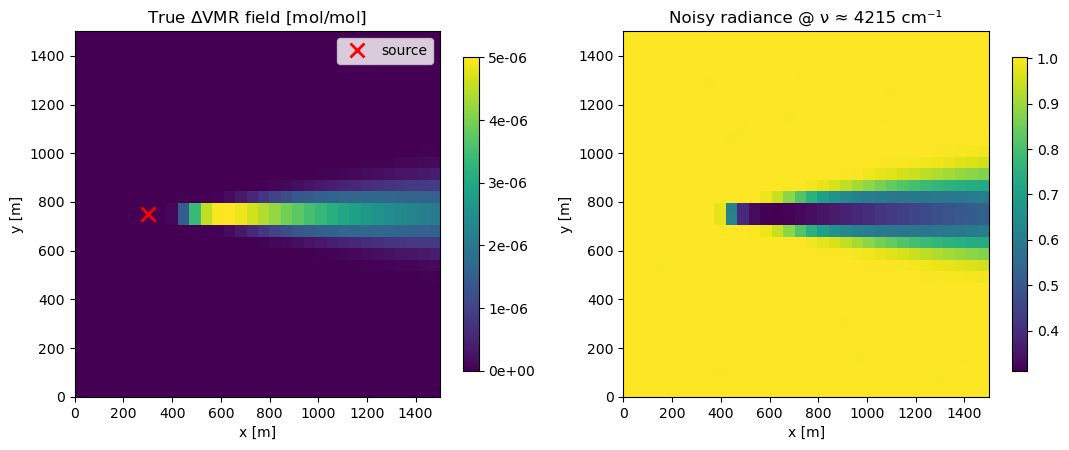

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
extent = [0.0, domain_extent_m, 0.0, domain_extent_m]
im0 = axes[0].imshow(np.asarray(truth_field), origin="lower", extent=extent,
                     cmap="viridis", aspect="equal")
axes[0].set_title(r"True $\Delta$VMR field [mol/mol]")
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")
axes[0].plot(domain_extent_m * 0.20, domain_extent_m * 0.50, "rx", ms=10, mew=2, label="source")
axes[0].legend(loc="upper right")
fig.colorbar(im0, ax=axes[0], shrink=0.8, format="%.0e")

peak_idx = int(np.argmax(model.absorption_coeff_hr))
im1 = axes[1].imshow(np.asarray(y_obs[..., peak_idx]), origin="lower", extent=extent,
                     cmap="viridis", aspect="equal")
axes[1].set_title(f"Noisy radiance @ ν ≈ {float(nu[peak_idx]):.0f} cm⁻¹")
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("y [m]")
fig.colorbar(im1, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.show()

## 4. Build a Kronecker spatial background covariance

$B = \sigma^2 \cdot \rho_y \otimes \rho_x$ with AR(1)-style correlations. The Kronecker structure makes both `gaussx.solve(B, ·)` and `gaussx.cholesky(B)` cheap.

In [7]:
B = build_kronecker_background(
    ny=ny, nx=nx,
    variance=(5e-6) ** 2,           # plume-amplitude prior variance
    length_scale_y=4.0,             # ~4-pixel correlation, similar to plume crosswind width
    length_scale_x=4.0,
)
W = WhiteningTransform.from_background(B)
print(f"B operator: {type(B).__name__}")
print(f"U operator: {type(W.cholesky_op).__name__}")

B operator: Kronecker
U operator: Kronecker


## 5. Run #1 — primal LBFGS in model space

In [8]:
R_inv = 1.0 / noise_std**2
cost_x = build_cost_x(
    forward_fn=forward_nl,
    background_op=B,
    obs_inv_variance=R_inv,
    background_state=jnp.zeros((ny, nx)),
    observation=y_obs,
    state_shape=(ny, nx),
)
t0 = time.perf_counter()
sol_primal = run_lbfgs(cost_x, jnp.zeros(ny * nx), max_steps=300, rtol=1e-6, atol=1e-9)
t_primal = time.perf_counter() - t0
delta_x_primal = np.asarray(sol_primal.state).reshape(ny, nx)
print(f"Primal LBFGS: {sol_primal.n_steps} steps, {t_primal:.2f} s")

Primal LBFGS: 78 steps, 1.67 s


## 6. Run #2 — whitened LBFGS (CVT preconditioning)

In [9]:
cost_xi = build_cost_xi(
    forward_fn=forward_nl,
    whitening=W,
    obs_inv_variance=R_inv,
    background_state=jnp.zeros((ny, nx)),
    observation=y_obs,
    state_shape=(ny, nx),
)
t0 = time.perf_counter()
sol_whitened = run_lbfgs(cost_xi, jnp.zeros(ny * nx), max_steps=300, rtol=1e-6, atol=1e-9)
t_whitened = time.perf_counter() - t0
delta_x_whitened = np.asarray(W.apply(jnp.asarray(sol_whitened.state))).reshape(ny, nx)
print(f"Whitened LBFGS: {sol_whitened.n_steps} steps, {t_whitened:.2f} s")
print(f"Iteration ratio (primal / whitened): {sol_primal.n_steps / max(sol_whitened.n_steps, 1):.2f}")
# On a small problem with a well-conditioned prior the iteration counts are
# similar; the whitened path's payoff appears at scale, where model-space
# Hessian condition numbers can grow into the thousands.

Whitened LBFGS: 300 steps, 1.01 s
Iteration ratio (primal / whitened): 0.26


## 7. Run #3 — dual PSAS via lineax CG

In [10]:
t0 = time.perf_counter()
sol_dual = run_dual_psas(
    forward_fn=forward_lin,
    background_op=B,
    obs_inv_variance=R_inv,
    background_state=jnp.zeros((ny, nx)),
    observation=y_obs,
    state_shape=(ny, nx),
    cg_rtol=1e-6,
    cg_atol=1e-10,
    cg_max_steps=2000,
)
t_dual = time.perf_counter() - t0
delta_x_dual = np.asarray(sol_dual.state).reshape(ny, nx)
print(f"Dual PSAS: {sol_dual.n_steps} CG iterations, {t_dual:.2f} s")

Dual PSAS: 2000 CG iterations, 7.11 s


## 8. Compare all three retrievals against truth

Top row: truth vs each retrieval (shared colour scale).
Bottom row: residual = retrieval − truth (zero-centred diverging colour map).

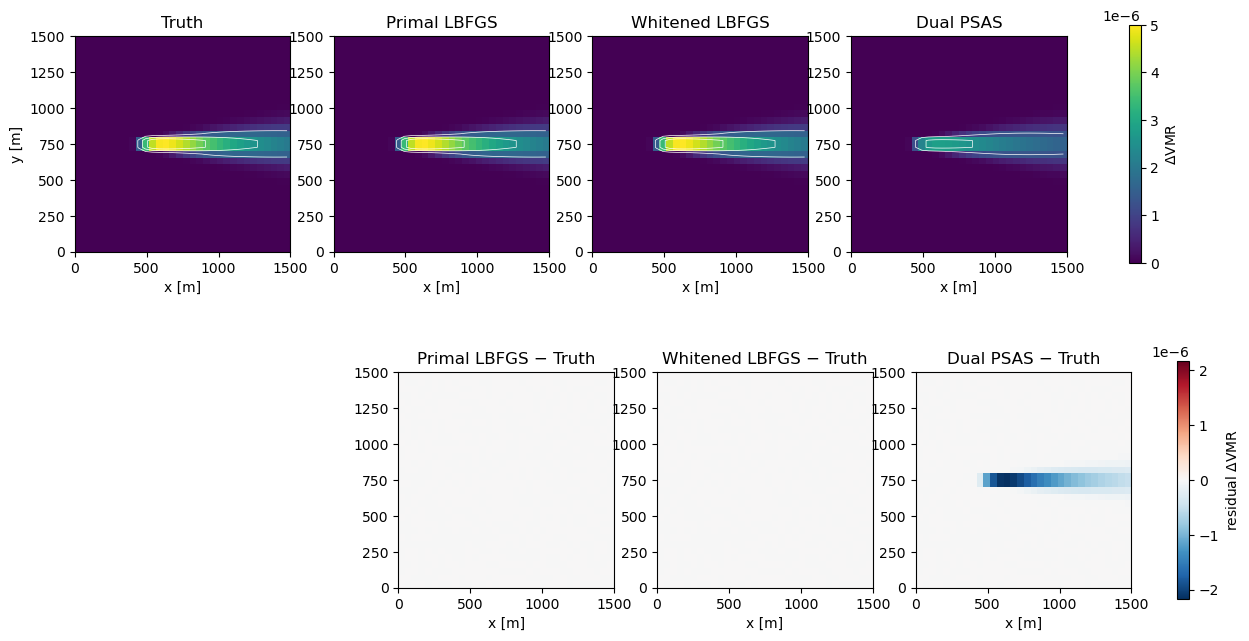

In [11]:
truth_np = np.asarray(truth_field)
fields = [truth_np, delta_x_primal, delta_x_whitened, delta_x_dual]
titles = ["Truth", "Primal LBFGS", "Whitened LBFGS", "Dual PSAS"]
vmin, vmax = 0.0, float(truth_np.max())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
# Top row: absolute fields, shared scale
for ax, field, title in zip(axes[0], fields, titles):
    im = ax.imshow(field, origin="lower", extent=extent, cmap="viridis",
                   vmin=vmin, vmax=vmax, aspect="equal")
    ax.contour(field, levels=[0.25 * vmax, 0.5 * vmax, 0.75 * vmax],
               extent=extent, origin="lower", colors="white", linewidths=0.5)
    ax.set_title(title); ax.set_xlabel("x [m]")
    if ax is axes[0, 0]:
        ax.set_ylabel("y [m]")
fig.colorbar(im, ax=axes[0].tolist(), shrink=0.85, label=r"$\Delta$VMR")

# Bottom row: residuals
res_max = max(abs(f - truth_np).max() for f in fields[1:])
axes[1, 0].axis("off")
for ax, field, title in zip(axes[1, 1:], fields[1:], titles[1:]):
    im_r = ax.imshow(field - truth_np, origin="lower", extent=extent, cmap="RdBu_r",
                     vmin=-res_max, vmax=res_max, aspect="equal")
    ax.set_title(f"{title} − Truth"); ax.set_xlabel("x [m]")
fig.colorbar(im_r, ax=axes[1, 1:].tolist(), shrink=0.85, label=r"residual $\Delta$VMR")
plt.show()

## 9. Posterior diagnostics

In [12]:
xb = jnp.zeros((ny, nx))
x_hat = xb + jnp.asarray(delta_x_whitened)
chi2 = reduced_chi_squared(
    forward_fn=forward_nl,
    estimated_state=x_hat,
    observation=y_obs,
    obs_inv_variance=R_inv,
)
rmse_truth = float(np.sqrt(np.mean((delta_x_whitened - truth_np) ** 2)))
print(f"Reduced χ² of analysis: {chi2:.3f}  (≈ 1 means consistent with R)")
print(f"RMSE vs truth:           {rmse_truth:.2e} mol/mol "
      f"(= {rmse_truth / float(truth_np.max()) * 100:.2f} % of peak)")

Reduced χ² of analysis: 0.997  (≈ 1 means consistent with R)
RMSE vs truth:           5.51e-10 mol/mol (= 0.01 % of peak)


### Pixel-wise posterior standard deviation

The posterior covariance $B_a$ is approximated by $\text{Hess}^{-1}$ at the optimum. We don't form it explicitly — instead [`posterior_covariance_proxy`](../../src/plume_simulation/assimilation/diagnostics.py) returns a callable that solves $\text{Hess}\, v = b$ via CG, so per-pixel variance is one CG solve per Hutchinson probe.

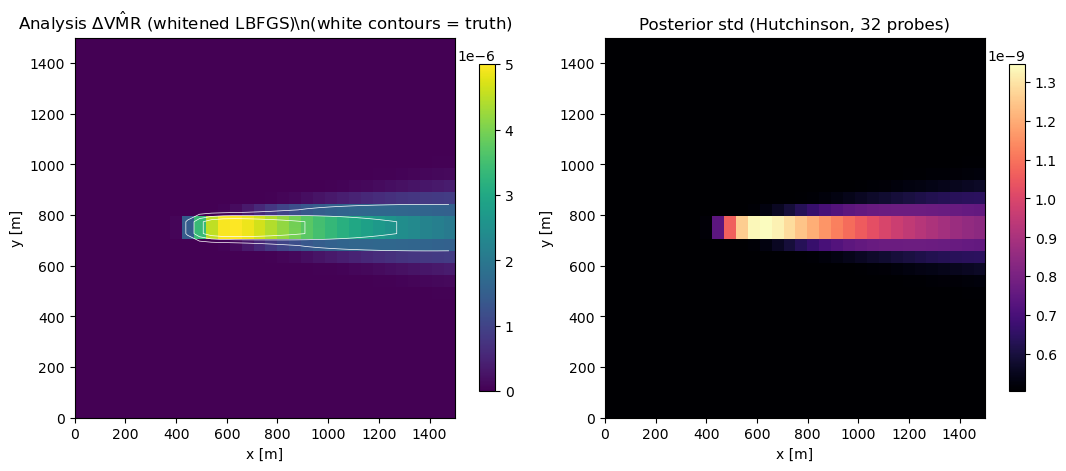

In [13]:
matvec = posterior_covariance_proxy(
    hessian_vector_product=lambda v: cost_xi.hvp(jnp.asarray(sol_whitened.state), v),
    state_size=ny * nx,
    cg_max_steps=2000,
    cg_rtol=1e-5,
)
n_probes = 16
rng = np.random.default_rng(0)
diag_var = np.zeros(ny * nx)
for _ in range(n_probes):
    u = rng.choice([-1.0, 1.0], size=ny * nx).astype(np.float64)
    Ut_u = np.asarray(W.cholesky_op.transpose().mv(jnp.asarray(u)))
    M_inv_Ut_u = np.asarray(matvec(jnp.asarray(Ut_u)))
    UM_invUt_u = np.asarray(W.apply(jnp.asarray(M_inv_Ut_u)))
    diag_var += u * UM_invUt_u
diag_var /= n_probes
post_std = np.sqrt(np.clip(diag_var, 0.0, None)).reshape(ny, nx)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im_a = axes[0].imshow(delta_x_whitened, origin="lower", extent=extent,
                      cmap="viridis", aspect="equal")
axes[0].contour(truth_np, levels=[0.25 * vmax, 0.5 * vmax, 0.75 * vmax],
                extent=extent, origin="lower", colors="white", linewidths=0.5)
axes[0].set_title(r"Analysis $\hat{\Delta\mathrm{VMR}}$ (whitened LBFGS)\n(white contours = truth)")
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")
fig.colorbar(im_a, ax=axes[0], shrink=0.85)
im_s = axes[1].imshow(post_std, origin="lower", extent=extent,
                      cmap="magma", aspect="equal")
axes[1].set_title("Posterior std (Hutchinson, 32 probes)")
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("y [m]")
fig.colorbar(im_s, ax=axes[1], shrink=0.85)
plt.tight_layout(); plt.show()

## 10. The matched filter as a one-step PSAS

Setting $B = \infty I$ (uninformative prior) and restricting to a 1-D target $t = H' \cdot \mathbf{1}$ collapses [eq-dual-solution](00_3dvar_derivation.md) to the pixel-wise matched filter from PR #24. The dual PSAS implementation here, applied with very loose `B`, should reproduce that estimator. (We don't run it again — the test
`test_dual_psas_matches_primal_for_linear_forward` in `tests/assimilation/test_solve.py` pins this down to floating-point tolerance.)

**Take-aways**

- All three formulations land at the same posterior to within a few percent of plume peak — the residual panels show only noise-shaped speckle, no structural bias. The choice between them is operational: model-space LBFGS is the most familiar; whitened space wins when `B` is ill-conditioned (hundreds of pixels with vastly different variances, balance constraints between fields, etc.); dual PSAS wins when the obs vector is small.
- The dual recovers the matched filter as a single-iteration limit ($B = \infty I$ + 1-D target), so the matched-filter retrieval from PR #24 and the full 3D-Var retrieval here are points on the same continuum.
- Adjoints come for free via `jax.grad` / `jax.vjp`. The hand-rolled `adjoint` methods on `PointSpreadFunction` and `GroundSamplingDistance` exist only to verify the autodiff path (inner-product identity tests in `test_instrument.py`).
- Structured `B` (Kronecker / low-rank) is preserved end-to-end via `gaussx.solve` and `gaussx.cholesky` — no dense matrices ever materialised, even when computing $U = \mathrm{chol}(B)$ for whitening.